# ☕ Cafe Sales Data Cleaning & Exploratory Analysis

## From Messy Transaction Data to Business Insights

This project analyzes a deliberately messy cafe sales dataset containing 10,000 transactions.

The project focuses on identifying and resolving data-quality issues, recovering missing values where they can be reliably derived, validating the cleaned dataset, and performing exploratory data analysis to uncover meaningful business insights.

**Tools:** Python · Pandas · NumPy · Matplotlib · Google Colab

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

# The previous attempt to load 'Cafe - Sales.csv' failed because the file was not found.
# The error message indicated that files can be accessed at '/kaggle/input/cafe-sales-dirty-data-for-cleaning-training'.
# Let's list the contents of that directory to identify the correct file name.
dataset_path = '/kaggle/input/cafe-sales-dirty-data-for-cleaning-training'
# print(f"Listing files in {dataset_path}:")
# for root, dirs, files in os.walk(dataset_path):
#     for file in files:
#         print(os.path.join(root, file))

# After inspecting the files, we found the correct file name.
file_path = "dirty_cafe_sales.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_1984/1143631429.py:20: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 537k/537k [00:00<00:00, 2.22MB/s]

First 5 records:   Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  


## 🎯 Project Objectives

The main objectives of this project are:

- Inspect the dataset and identify data-quality issues
- Handle missing and invalid values
- Standardize inconsistent values such as `ERROR` and `UNKNOWN`
- Convert columns to appropriate data types
- Validate transaction IDs and detect duplicates
- Recover missing financial values using logical business rules
- Validate relationships between quantity, price, and total spending
- Handle invalid and missing transaction dates
- Preserve values that cannot be reliably recovered
- Explore sales performance and transaction patterns
- Generate business insights and recommendations

The goal is not simply to remove missing values, but to determine **whether each missing value can be reliably recovered from the available information**.

In [ ]:
import pandas as pd
import numpy as np
import plotly as plt

## 📂 Dataset

The dataset contains **10,000 cafe transactions** and 8 original business columns.

| Column | Description |
|---|---|
| `transaction_id` | Unique transaction identifier |
| `item` | Product purchased |
| `quantity` | Number of units purchased |
| `price_per_unit` | Price of one unit |
| `total_spent` | Total amount spent in the transaction |
| `payment_method` | Payment method used |
| `location` | Transaction location |
| `transaction_date` | Date of the transaction |

The dataset was intentionally designed to contain messy and inconsistent data, making it useful for practicing real-world data cleaning and validation.

In [ ]:
df_raw=df.copy()

# 🧹 1. Data Quality Assessment

Before modifying the dataset, I first performed an initial data-quality assessment.

The inspection focused on:

- Dataset dimensions and structure
- Missing values
- Data types
- Duplicate records
- Transaction ID validity
- Invalid numeric values
- Categorical inconsistencies
- Financial consistency
- Transaction date validity

This establishes a baseline against which the cleaned dataset can later be compared.

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 10000
Columns: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [ ]:
df.describe().T

,count,unique,top,freq
Transaction ID,10000,10000,TXN_9226047,1
Item,9667,10,Juice,1171
Quantity,9862,7,5,2013
Price Per Unit,9821,8,3.0,2429
Total Spent,9827,19,6.0,979
Payment Method,7421,5,Digital Wallet,2291
Location,6735,4,Takeaway,3022
Transaction Date,9841,367,UNKNOWN,159


In [ ]:
df.dtypes

,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


In [ ]:
missing=pd.DataFrame({
    "Missing Count":df.isnull().sum(),
    "Missing %":df.isnull().mean()*100
})
missing.sort_values("Missing %",ascending=False)

,Missing Count,Missing %
Location,3265,32.65
Payment Method,2579,25.79
Item,333,3.33
Price Per Unit,179,1.79
Total Spent,173,1.73
Transaction Date,159,1.59
Quantity,138,1.38
Transaction ID,0,0.00


In [ ]:
df[df.isna().any(axis=1)]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31
13,TXN_9437049,Cookie,5,1.0,5.0,NaN,Takeaway,2023-06-01
14,TXN_8915701,ERROR,2,1.5,3.0,NaN,In-store,2023-03-21
...,...,...,...,...,...,...,...,...
9994,TXN_7851634,UNKNOWN,4,4.0,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02


In [ ]:
for col in df.select_dtypes(include="object").columns:
    print(f"{col}:")
    print(df[col].value_counts(dropna=False))


Transaction ID:
Transaction ID
TXN_9226047    1
TXN_8567525    1
TXN_4583012    1
TXN_6796890    1
TXN_9933628    1
              ..
TXN_3160411    1
TXN_7034554    1
TXN_4271903    1
TXN_4977031    1
TXN_1961373    1
Name: count, Length: 10000, dtype: int64
Item:
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64
Quantity:
Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
NaN         138
Name: count, dtype: int64
Price Per Unit:
Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
NaN         179
UNKNOWN     164
Name: count, dtype: int64
Total Spent:
Total Spent
6.0        979
12.0       939
3.0        930
4.0        923
20.0       746
15.0       734
8.0        677
10.0       52

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Transaction ID"].astype(str).str.startswith("TXN_").value_counts()

,count
Transaction ID,
True,10000


In [ ]:
df[pd.to_numeric(df["Quantity"], errors='coerce') < 0]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


In [ ]:
df[pd.to_numeric(df["Quantity"], errors='coerce') == 0]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


In [ ]:
df[pd.to_numeric(df["Price Per Unit"], errors='coerce') < 0]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


In [ ]:
df[pd.to_numeric(df["Price Per Unit"], errors='coerce') == 0]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


In [ ]:
df[pd.to_numeric(df["Total Spent"], errors='coerce') < 0]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


In [ ]:
df[pd.to_numeric(df["Total Spent"], errors='coerce') == 0]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


In [ ]:
df.columns=(
    df.columns.str.strip().str.lower().str.replace(" ","_").str.replace("-","")
)
df.columns

Index(['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date'],
      dtype='object')

In [ ]:
quantity=pd.to_numeric(df["quantity"], errors='coerce')
price_per_unit=pd.to_numeric(df["price_per_unit"], errors='coerce')
total_spent=pd.to_numeric(df["total_spent"], errors='coerce')
item=df["item"]
expected_total=quantity*price_per_unit

In [ ]:
total_check=pd.DataFrame({
    "Transaction ID":df["transaction_id"],
    "Item":item,
    "Quantity":quantity,
    "Price Per Unit":price_per_unit,
    "Expected Total":expected_total,
    "Total Spent":total_spent
})
total_check["Difference"]=total_check["Total Spent"]-total_check["Expected Total"]
total_check.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Expected Total,Total Spent,Difference
0,TXN_1961373,Coffee,2.0,2.0,4.0,4.0,0.0
1,TXN_4977031,Cake,4.0,3.0,12.0,12.0,0.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,NaN,NaN
3,TXN_7034554,Salad,2.0,5.0,10.0,10.0,0.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,4.0,0.0
5,TXN_2602893,Smoothie,5.0,4.0,20.0,20.0,0.0
6,TXN_4433211,UNKNOWN,3.0,3.0,9.0,9.0,0.0
7,TXN_6699534,Sandwich,4.0,4.0,16.0,16.0,0.0
8,TXN_4717867,NaN,5.0,3.0,15.0,15.0,0.0
9,TXN_2064365,Sandwich,5.0,4.0,20.0,20.0,0.0


In [ ]:
mismatches = total_check[
    total_check["Difference"].abs() > 0.01
]

mismatches

,Transaction ID,Item,Quantity,Price Per Unit,Expected Total,Total Spent,Difference


In [ ]:
total_check['Difference'].value_counts(dropna=False)

,count
Difference,
0.0,8544
NaN,1456


In [ ]:
cannot_validate = total_check[
    total_check["Quantity"].isna() |
    total_check["Price Per Unit"].isna() |
    total_check["Total Spent"].isna()
]

print("Cannot validate:", len(cannot_validate))

Cannot validate: 1456


In [ ]:
cannot_validate.head()

,Transaction ID,Item,Quantity,Price Per Unit,Expected Total,Total Spent,Difference
2,TXN_4271903,Cookie,4.0,1.0,4.0,NaN,NaN
20,TXN_3522028,Smoothie,NaN,4.0,NaN,20.0,NaN
25,TXN_7958992,Smoothie,3.0,4.0,12.0,NaN,NaN
31,TXN_8927252,UNKNOWN,2.0,1.0,2.0,NaN,NaN
42,TXN_6650263,Tea,2.0,1.5,3.0,NaN,NaN


In [ ]:
total_check.groupby("Item")["Price Per Unit"].agg(
    ["count", "nunique", "min", "max", "mean"]
)

,count,nunique,min,max,mean
Item,,,,,
Cake,1085,1,3.0,3.0,3.000000
Coffee,1108,1,2.0,2.0,2.000000
Cookie,1026,1,1.0,1.0,1.000000
ERROR,279,6,1.0,5.0,2.944444
Juice,1110,1,3.0,3.0,3.000000
Salad,1082,1,5.0,5.0,5.000000
Sandwich,1082,1,4.0,4.0,4.000000
Smoothie,1036,1,4.0,4.0,4.000000
Tea,1023,1,1.5,1.5,1.500000


In [ ]:
total_check.groupby(["Item","Price Per Unit"],dropna=False).size().sort_values(ascending=False)

,,0
Item,Price Per Unit,
Juice,3.0,1110
Coffee,2.0,1108
Cake,3.0,1085
Salad,5.0,1082
Sandwich,4.0,1082
Smoothie,4.0,1036
Cookie,1.0,1026
Tea,1.5,1023
NaN,4.0,82


In [ ]:
transaction_date = pd.to_datetime(
    df["transaction_date"],
    errors="coerce"
)

In [ ]:
print("Invalid/unparseable dates:",

      transaction_date.isna().sum() - df["transaction_date"].isna().sum())

Invalid/unparseable dates: 301


In [ ]:
print("Earliest:", transaction_date.min())
print("Latest:", transaction_date.max())

Earliest: 2023-01-01 00:00:00
Latest: 2023-12-31 00:00:00


In [ ]:
valid_items = [
    "Coffee", "Cake", "Cookie", "Juice",
    "Salad", "Sandwich", "Smoothie", "Tea"
]

missing_price_for_known_item = df[
    df["item"].isin(valid_items) &
    df["price_per_unit"].isna()
]
missing_price_for_known_item

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
56,TXN_3578141,Cake,5,NaN,15.0,NaN,Takeaway,2023-06-27
65,TXN_4987129,Sandwich,3,NaN,NaN,NaN,In-store,2023-10-20
85,TXN_8035512,Tea,3,NaN,4.5,Cash,UNKNOWN,2023-10-29
104,TXN_7447872,Juice,2,NaN,6.0,NaN,NaN,NaN
164,TXN_1435086,Cake,5,NaN,15.0,NaN,ERROR,2023-02-09
...,...,...,...,...,...,...,...,...
9643,TXN_9147596,Coffee,2,NaN,4.0,Digital Wallet,Takeaway,2023-10-08
9738,TXN_4663964,Cookie,4,NaN,4.0,Digital Wallet,In-store,2023-06-29
9893,TXN_3809533,Juice,2,NaN,ERROR,Digital Wallet,Takeaway,2023-02-02
9924,TXN_5981429,Juice,2,NaN,6.0,Digital Wallet,NaN,2023-12-24


In [ ]:
invalid_price = df[
    df["price_per_unit"].isin(["ERROR", "UNKNOWN"])
]

print("ERROR/UNKNOWN prices:", len(invalid_price))

invalid_price.head()

ERROR/UNKNOWN prices: 354


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
68,TXN_8427104,Salad,2,ERROR,10.0,NaN,In-store,2023-10-27
140,TXN_2484241,Cake,3,UNKNOWN,9.0,Digital Wallet,NaN,2023-07-19
147,TXN_9336980,Salad,4,UNKNOWN,20.0,Cash,In-store,2023-06-06
161,TXN_7965998,Juice,1,UNKNOWN,3.0,Credit Card,In-store,2023-11-02
162,TXN_9238666,Cookie,1,UNKNOWN,1.0,ERROR,Takeaway,2023-07-31


In [ ]:
recoverable_price=df[
    (df["item"].isin(valid_items)) &
    (df["price_per_unit"].isin(["ERROR", "UNKNOWN"])|df['price_per_unit'].isna())
]
print("Known item + invalid/missing price:",
      len(recoverable_price))
recoverable_price.head(10)

Known item + invalid/missing price: 479


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
56,TXN_3578141,Cake,5,NaN,15.0,NaN,Takeaway,2023-06-27
65,TXN_4987129,Sandwich,3,NaN,NaN,NaN,In-store,2023-10-20
68,TXN_8427104,Salad,2,ERROR,10.0,NaN,In-store,2023-10-27
85,TXN_8035512,Tea,3,NaN,4.5,Cash,UNKNOWN,2023-10-29
104,TXN_7447872,Juice,2,NaN,6.0,NaN,NaN,NaN
140,TXN_2484241,Cake,3,UNKNOWN,9.0,Digital Wallet,NaN,2023-07-19
147,TXN_9336980,Salad,4,UNKNOWN,20.0,Cash,In-store,2023-06-06
161,TXN_7965998,Juice,1,UNKNOWN,3.0,Credit Card,In-store,2023-11-02
162,TXN_9238666,Cookie,1,UNKNOWN,1.0,ERROR,Takeaway,2023-07-31
164,TXN_1435086,Cake,5,NaN,15.0,NaN,ERROR,2023-02-09


In [ ]:
clean_df=df.copy()
clean_df.columns

Index(['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date'],
      dtype='object')

## Standardizing Invalid Values

The dataset contains placeholder values such as `ERROR` and `UNKNOWN`.

These values do not represent meaningful business information, so they are converted to `NaN`.

This allows Pandas to treat them consistently as missing values during subsequent cleaning and analysis.

In [ ]:
clean_df=clean_df.replace(
    ["ERROR","UNKNOWN"],
    np.nan
)
clean_df.isna().sum()

,0
transaction_id,0
item,969
quantity,479
price_per_unit,533
total_spent,502
payment_method,3178
location,3961
transaction_date,460


## Data Type Conversion

The original dataset contains several columns stored as text even though they represent numeric or date information.

The following conversions are performed:

- `quantity` → numeric
- `price_per_unit` → numeric
- `total_spent` → numeric
- `transaction_date` → datetime

Invalid values that cannot be converted are coerced to missing values rather than being assigned arbitrary replacements.

In [ ]:
numeric_cols=["quantity","price_per_unit","total_spent"]
for col in numeric_cols:
    clean_df[col]=pd.to_numeric(clean_df[col],errors="coerce")
clean_df[numeric_cols].dtypes

,0
quantity,float64
price_per_unit,float64
total_spent,float64


In [ ]:
clean_df["transaction_date"]=pd.to_datetime(
    clean_df["transaction_date"],
    errors="coerce"
)


In [ ]:
price_map = {
    "Coffee": 2.0,
    "Cake": 3.0,
    "Cookie": 1.0,
    "Juice": 3.0,
    "Salad": 5.0,
    "Sandwich": 4.0,
    "Smoothie": 4.0,
    "Tea": 1.5
}

## Recovering Missing Prices

The cafe menu contains a known price for each valid product.

Therefore, when the product is known but `price_per_unit` is missing, the price can be recovered using the corresponding menu price.

This is considered a reliable recovery because the relationship between product and price is explicitly defined in the dataset.

In [ ]:
missing_price_before=clean_df['price_per_unit'].isna().sum()
clean_df['price_per_unit']=(
    clean_df['price_per_unit'].fillna(
        clean_df['item'].map(price_map)
    )
)
missing_price_after=clean_df['price_per_unit'].isna().sum()
print("Missing price before:", missing_price_before)
print("Missing price after:", missing_price_after)
print("Prices recovered:",missing_price_before-missing_price_after)

Missing price before: 533
Missing price after: 54
Prices recovered: 479


In [ ]:
derived_price=(
    clean_df["total_spent"]/clean_df["quantity"]
)

In [ ]:
valid_prices=set(price_map.values())
price_from_total=derived_price.where(derived_price.isin(valid_prices))

In [ ]:
clean_df['price_per_unit']=(clean_df['price_per_unit'].fillna(price_from_total))
clean_df['price_per_unit'].isna().sum()

np.int64(6)

## Recovering Missing Quantities and Totals

Additional financial relationships can be used to recover some missing values.

When total spending and unit price are available:

**Quantity = Total Spent ÷ Price Per Unit**

Only quantities within the expected range of 1–5 are accepted.

When quantity and unit price are available:

**Total Spent = Quantity × Price Per Unit**

Values are recovered only when the calculation produces a valid result.

In [ ]:
derived_quantity = (
    clean_df["total_spent"] /
    clean_df["price_per_unit"]
)


In [ ]:
mask=(
    clean_df["quantity"].isna()&
    derived_quantity.notna() &
    derived_quantity.isin([1,2,3,4,5])
)
clean_df.loc[mask,"quantity"]=derived_quantity.loc[mask]
clean_df["quantity"]=clean_df["quantity"].astype("Int64")

In [ ]:
calculated_total = (
    clean_df["quantity"] *
    clean_df["price_per_unit"]
)

In [ ]:
clean_df["total_spent"] = (
    clean_df["total_spent"]
    .fillna(calculated_total)
)


In [ ]:
clean_df["price_per_unit"] = (
    clean_df["price_per_unit"].round(2)
)

clean_df["total_spent"] = (
    clean_df["total_spent"].round(2)
)

## Recovering Missing Product Information

Some transactions have a missing product value.

When the available price uniquely identifies a product, the product can be recovered with reasonable confidence.

For example, a price that corresponds to only one product in the menu can be used to infer the missing item.

Ambiguous cases are left missing rather than making unsupported assumptions.

In [ ]:
unique_price_to_item = {
    2.0: "Coffee",
    1.0: "Cookie",
    5.0: "Salad",
    1.5: "Tea"
}

In [ ]:
clean_df["item"] = (
    clean_df["item"]
    .fillna(clean_df["price_per_unit"].map(unique_price_to_item))
)


## 💰 Financial Consistency Check

The dataset contains three related financial fields:

- Quantity
- Price per Unit
- Total Spent

The expected transaction total is calculated using:

**Total Spent = Quantity × Price Per Unit**

This relationship is used both to identify inconsistent records and to recover missing financial values where sufficient information is available.

In [ ]:
clean_df["expected_total"] = (
    clean_df["quantity"] *
    clean_df["price_per_unit"]
)

clean_df["total_difference"] = (
    clean_df["total_spent"] -
    clean_df["expected_total"]
)

clean_mismatches = clean_df[
    clean_df["total_difference"].abs() > 0.01
]

print("Remaining total mismatches:",
      len(clean_mismatches))

Remaining total mismatches: 0


In [ ]:
clean_df['payment_method']=(
    clean_df['payment_method'].astype("category")
)
clean_df['location']=(
    clean_df['location'].astype("category")
)
clean_df['item']=(
    clean_df['item'].astype("category")
)

In [ ]:
clean_df["expected_total"]=clean_df["quantity"]*clean_df["price_per_unit"]

In [ ]:
unresolved_financial=clean_df[
    clean_df[
        ["quantity", "price_per_unit", "total_spent"]
    ].isna().any(axis=1)
]
print("Unresolved financial issues:", len(unresolved_financial))

unresolved_financial.head(10)

Unresolved financial issues: 26


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,expected_total,total_difference
236,TXN_8562645,Salad,<NA>,5.0,<NA>,NaN,In-store,2023-05-18,<NA>,<NA>
278,TXN_3229409,Juice,<NA>,3.0,<NA>,Cash,Takeaway,2023-04-15,<NA>,<NA>
641,TXN_2962976,Juice,<NA>,3.0,<NA>,NaN,NaN,2023-03-17,<NA>,<NA>
738,TXN_8696094,Sandwich,<NA>,4.0,<NA>,NaN,Takeaway,2023-05-14,<NA>,<NA>
1761,TXN_3611851,NaN,4,NaN,<NA>,Credit Card,NaN,2023-02-09,<NA>,<NA>
2289,TXN_7524977,NaN,4,NaN,<NA>,NaN,NaN,2023-12-09,<NA>,<NA>
2796,TXN_9188692,Cake,<NA>,3.0,<NA>,Credit Card,NaN,2023-12-01,<NA>,<NA>
3203,TXN_4565754,Smoothie,<NA>,4.0,<NA>,Digital Wallet,Takeaway,2023-10-06,<NA>,<NA>
3224,TXN_6297232,Coffee,<NA>,2.0,<NA>,NaN,NaN,2023-04-07,<NA>,<NA>
3401,TXN_3251829,Tea,<NA>,1.5,<NA>,Digital Wallet,In-store,2023-07-25,<NA>,<NA>


In [ ]:
missing_after = pd.DataFrame({
    "Missing Count": clean_df.isna().sum(),
    "Missing %": clean_df.isna().mean() * 100
})

missing_after.sort_values(
    "Missing Count",
    ascending=False
)

,Missing Count,Missing %
location,3961,39.61
payment_method,3178,31.78
item,480,4.80
transaction_date,460,4.60
total_difference,26,0.26
expected_total,26,0.26
total_spent,23,0.23
quantity,23,0.23
price_per_unit,6,0.06
transaction_id,0,0.00


In [ ]:
clean_df["quantity"].value_counts(dropna=False).sort_index()

,count
quantity,
1,1926
2,2056
3,1946
4,1941
5,2108
<NA>,23


In [ ]:
clean_df["price_per_unit"].value_counts(dropna=False).sort_index()

,count
price_per_unit,
1.0,1213
1.5,1207
2.0,1291
3.0,2557
4.0,2454
5.0,1272
NaN,6


In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  object        
 1   item              9520 non-null   category      
 2   quantity          9977 non-null   Int64         
 3   price_per_unit    9994 non-null   float64       
 4   total_spent       9977 non-null   Float64       
 5   payment_method    6822 non-null   category      
 6   location          6039 non-null   category      
 7   transaction_date  9540 non-null   datetime64[ns]
 8   expected_total    9974 non-null   Float64       
 9   total_difference  9974 non-null   Float64       
dtypes: Float64(3), Int64(1), category(3), datetime64[ns](1), float64(1), object(1)
memory usage: 616.0+ KB


In [ ]:
clean_df.describe(include="all")

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,expected_total,total_difference
count,10000,9520,9977.0,9994.000000,9977.0,6822,6039,9540,9974.0,9974.0
unique,10000,8,<NA>,NaN,<NA>,3,2,NaN,<NA>,<NA>
top,TXN_9226047,Coffee,<NA>,NaN,<NA>,Digital Wallet,Takeaway,NaN,<NA>,<NA>
freq,1,1291,<NA>,NaN,<NA>,2291,3022,NaN,<NA>,<NA>
mean,NaN,NaN,3.024957,2.947018,8.930139,NaN,NaN,2023-07-01 23:00:31.698113280,8.927411,0.0
min,NaN,NaN,1.0,1.000000,1.0,NaN,NaN,2023-01-01 00:00:00,1.0,0.0
25%,NaN,NaN,2.0,2.000000,4.0,NaN,NaN,2023-04-01 00:00:00,4.0,0.0
50%,NaN,NaN,3.0,3.000000,8.0,NaN,NaN,2023-07-02 00:00:00,8.0,0.0
75%,NaN,NaN,4.0,4.000000,12.0,NaN,NaN,2023-10-02 00:00:00,12.0,0.0
max,NaN,NaN,5.0,5.000000,25.0,NaN,NaN,2023-12-31 00:00:00,25.0,0.0


In [ ]:
comparison = pd.DataFrame({
    "Before": df.isna().sum(),
    "After": clean_df.isna().sum()
})

comparison["Recovered"] = (
    comparison["Before"] -
    comparison["After"]
)

comparison

,Before,After,Recovered
expected_total,NaN,26,NaN
item,333.0,480,-147.0
location,3265.0,3961,-696.0
payment_method,2579.0,3178,-599.0
price_per_unit,179.0,6,173.0
quantity,138.0,23,115.0
total_difference,NaN,26,NaN
total_spent,173.0,23,150.0
transaction_date,159.0,460,-301.0
transaction_id,0.0,0,0.0


In [ ]:
clean_df.drop(columns=["expected_total","total_difference"],inplace=True)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  object        
 1   item              9520 non-null   category      
 2   quantity          9977 non-null   Int64         
 3   price_per_unit    9994 non-null   float64       
 4   total_spent       9977 non-null   Float64       
 5   payment_method    6822 non-null   category      
 6   location          6039 non-null   category      
 7   transaction_date  9540 non-null   datetime64[ns]
dtypes: Float64(1), Int64(1), category(3), datetime64[ns](1), float64(1), object(1)
memory usage: 440.2+ KB


In [ ]:
clean_df.to_csv("cafe_sales_cleaned.csv",index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  object        
 1   item              9520 non-null   category      
 2   quantity          9977 non-null   Int64         
 3   price_per_unit    9994 non-null   float64       
 4   total_spent       9977 non-null   Float64       
 5   payment_method    6822 non-null   category      
 6   location          6039 non-null   category      
 7   transaction_date  9540 non-null   datetime64[ns]
dtypes: Float64(1), Int64(1), category(3), datetime64[ns](1), float64(1), object(1)
memory usage: 440.2+ KB


# 📊 2. Exploratory Data Analysis

After completing the data cleaning and validation process, the cleaned dataset is analyzed to understand sales performance and transaction patterns.

The analysis focuses on:

1. Overall sales performance
2. Product performance
3. Monthly sales trends
4. Day-of-week performance
5. Payment methods
6. Transaction locations

The goal is to move from **data quality → analysis → business interpretation**.

In [ ]:
# ==========================================
# KEY BUSINESS METRICS
# ==========================================

total_revenue = clean_df["total_spent"].sum()
total_transactions = clean_df["transaction_id"].nunique()
total_items_sold = clean_df["quantity"].sum()
average_transaction_value = clean_df["total_spent"].mean()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Items Sold: {total_items_sold:,}")
print(f"Average Transaction Value: ${average_transaction_value:,.2f}")

Total Revenue: $89,096.00
Total Transactions: 10,000
Total Items Sold: 30,180
Average Transaction Value: $8.93


## 🥗 Product Performance

Product-level analysis is used to determine which products contribute most to sales.

Two perspectives are particularly important:

- **Units sold** — measures product volume and popularity
- **Revenue** — measures financial contribution

A product with high unit sales does not necessarily generate the highest revenue because products have different prices.

In [ ]:
product_sales = (
    clean_df
    .groupby("item", observed=True)
    .agg(
        units_sold=("quantity", "sum"),
        revenue=("total_spent", "sum"),
        transactions=("transaction_id", "nunique")
    )
    .sort_values("revenue", ascending=False)
)


In [ ]:
product_sales['revenue_share_%']=(
    round(product_sales['revenue']/total_revenue*100,2)
)
product_sales

,units_sold,revenue,transactions,revenue_share_%
item,,,,
Salad,3819,19095.0,1272,21.43
Sandwich,3429,13716.0,1131,15.39
Smoothie,3336,13344.0,1096,14.98
Juice,3505,10515.0,1171,11.8
Cake,3468,10404.0,1139,11.68
Coffee,3904,7808.0,1291,8.76
Tea,3650,5475.0,1207,6.15
Cookie,3598,3598.0,1213,4.04


In [ ]:
product_analysis=(
    clean_df.groupby("item").agg(
        avg_price=("price_per_unit","mean"),
        units_sold=("quantity","sum"),
        revenue=("total_spent","sum"),
        transactions=("transaction_id","nunique")
    )
)
product_analysis["revenue_share_%"] = (
    product_analysis["revenue"] / total_revenue * 100
).round(2)

product_analysis

/tmp/ipykernel_1984/2074076055.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_df.groupby("item").agg(


,avg_price,units_sold,revenue,transactions,revenue_share_%
item,,,,,
Cake,3.0,3468,10404.0,1139,11.68
Coffee,2.0,3904,7808.0,1291,8.76
Cookie,1.0,3598,3598.0,1213,4.04
Juice,3.0,3505,10515.0,1171,11.8
Salad,5.0,3819,19095.0,1272,21.43
Sandwich,4.0,3429,13716.0,1131,15.39
Smoothie,4.0,3336,13344.0,1096,14.98
Tea,1.5,3650,5475.0,1207,6.15


### Revenue by Product

The following visualization compares total revenue generated by each product.

This helps identify the products that contribute most strongly to overall sales.

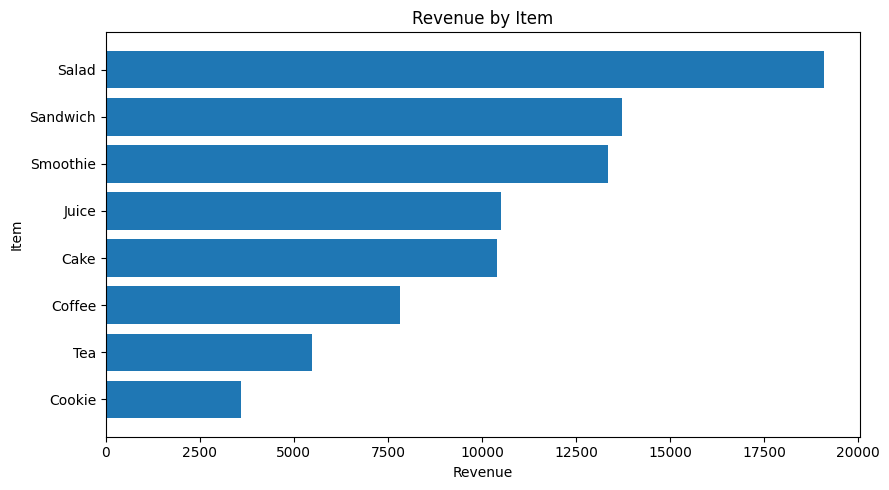

In [ ]:
import matplotlib.pyplot as plt

product_analysis_sorted=product_analysis.sort_values("revenue",ascending=False)
plt.figure(figsize=(9, 5))
plt.barh(product_analysis_sorted.index, product_analysis_sorted["revenue"])
plt.xlabel("Revenue")
plt.ylabel("Item")
plt.title("Revenue by Item")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 📅 Sales Trends Over Time

Transaction dates are used to investigate whether sales vary throughout the year and across different days of the week.

Because some transaction dates are missing or invalid, time-based analysis is performed only on records with valid transaction dates.

Missing dates are not artificially imputed because there is insufficient information to determine their correct values.

In [ ]:
# ==========================================
# TIME FEATURES
# ==========================================

clean_df["year"] = clean_df["transaction_date"].dt.year
clean_df["month"] = clean_df["transaction_date"].dt.month
clean_df["month_name"] = clean_df["transaction_date"].dt.month_name()
clean_df["day_of_week"] = clean_df["transaction_date"].dt.day_name()

print("Rows with valid dates:", clean_df["transaction_date"].notna().sum())


Rows with valid dates: 9540


### Monthly Revenue

Monthly revenue is analyzed to identify potential seasonal patterns, peaks, or periods of weaker sales activity.

In [ ]:
monthly_sales=(
    clean_df.dropna(subset=["transaction_date"])
    .groupby("month",observed=True)
    .agg(
        revenue=("total_spent","sum"),
        transactions=("transaction_id","nunique"),
        units_sold=("quantity","sum")
    )
)
monthly_sales["avg_transaction_value"]=(
    monthly_sales["revenue"]/monthly_sales["transactions"]
)
monthly_sales.round(2)


,revenue,transactions,units_sold,avg_transaction_value
month,,,,
1.0,7254.0,818,2448,8.87
2.0,6644.0,727,2257,9.14
3.0,7216.0,827,2470,8.73
4.0,7179.0,774,2373,9.28
5.0,6957.5,777,2332,8.95
6.0,7353.0,818,2461,8.99
7.0,6877.5,791,2337,8.69
8.0,7112.5,803,2410,8.86
9.0,6871.0,788,2358,8.72


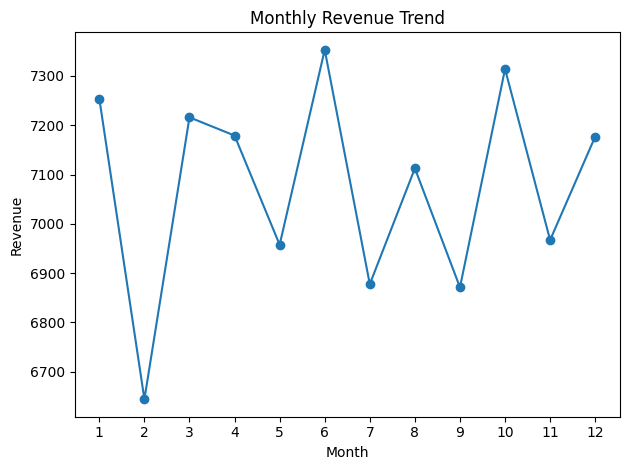

In [ ]:
plt.plot(
    monthly_sales.index,
    monthly_sales["revenue"],
    marker="o"
    )
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

### Revenue by Day of Week

Revenue is compared across the seven days of the week to identify differences in sales activity.

This can help determine whether particular days consistently generate higher transaction volume or revenue.

In [ ]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekly_sales = (
    clean_df.dropna(subset=["transaction_date"])
    .groupby("day_of_week", observed=True)
    .agg(
        revenue=("total_spent", "sum"),
        transactions=("transaction_id", "nunique"),
        units_sold=("quantity", "sum")
    ).reindex(day_order)
)
weekly_sales["avg_transaction_value"] = (
    round(weekly_sales["revenue"] / weekly_sales["transactions"],2)
)
weekly_sales.sort_values("revenue", ascending=False)

,revenue,transactions,units_sold,avg_transaction_value
day_of_week,,,,
Thursday,12401.5,1380,4189,8.99
Friday,12334.0,1388,4200,8.89
Sunday,12287.5,1380,4156,8.9
Monday,12140.0,1382,4127,8.78
Tuesday,12039.5,1311,4068,9.18
Saturday,12039.5,1358,4062,8.87
Wednesday,11680.5,1341,3952,8.71


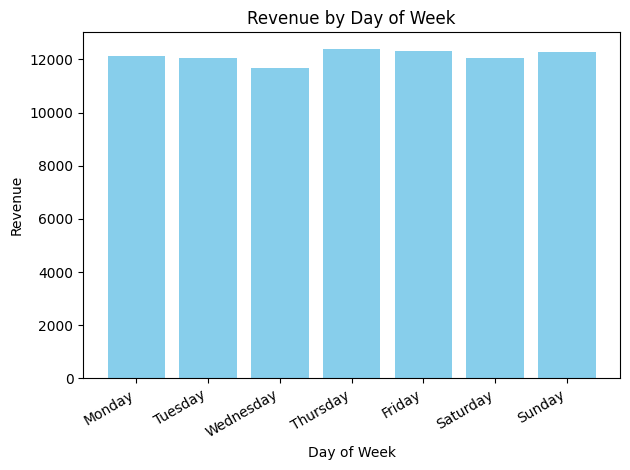

In [ ]:
plt.bar(
    weekly_sales.index,
    weekly_sales["revenue"],
    tick_label=weekly_sales.index,
    color="skyblue"
)

plt.xticks(rotation=30, ha="right")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.title("Revenue by Day of Week")

plt.tight_layout()
plt.show()

## 💳 Payment Method & 📍 Location Analysis

Payment method and transaction location are analyzed to understand customer transaction behavior.

Because these fields contain a substantial proportion of missing values, the analysis uses only records where the corresponding information is available.

The results should therefore be interpreted as patterns among **known values**, rather than estimates for the entire dataset.

In [ ]:
payment_analysis=(
    clean_df.dropna(subset=["payment_method"])
    .groupby("payment_method",observed=True)
    .agg(
        revenue=("total_spent","sum"),
        transactions=("transaction_id","nunique"),
        units_sold=("quantity","sum")
                  )
)
payment_analysis["revenue_share_%"] = (
    payment_analysis["revenue"] /
    payment_analysis["revenue"].sum() * 100
).round(2)
payment_analysis

,revenue,transactions,units_sold,revenue_share_%
payment_method,,,,
Cash,20402.5,2258,6841,33.29
Credit Card,20466.0,2273,6850,33.4
Digital Wallet,20414.0,2291,6933,33.31


In [ ]:
location_analysis = (
    clean_df
    .dropna(subset=["location"])
    .groupby("location", observed=True)
    .agg(
        transactions=("transaction_id", "nunique"),
        revenue=("total_spent", "sum"),
        units_sold=("quantity", "sum")
    )
)

location_analysis["revenue_share_%"] = (
    location_analysis["revenue"] /
    location_analysis["revenue"].sum() * 100
).round(2)

location_analysis

,transactions,revenue,units_sold,revenue_share_%
location,,,,
In-store,3017,27174.0,9133,50.58
Takeaway,3022,26552.5,9144,49.42


## Overall Sales Performance

The first step is to establish a baseline using four key metrics:

- Total revenue
- Total transactions
- Total items sold
- Average transaction value

These metrics provide an overall picture of the cafe's sales activity before examining individual products or time periods.

In [ ]:
# ==========================================
# FINAL EDA METRICS
# ==========================================

print("===== OVERALL =====")
print(f"Total revenue: {total_revenue:,.2f}")
print(f"Total transactions: {total_transactions:,}")
print(f"Total items sold: {total_items_sold:,}")
print(f"Average transaction value: {average_transaction_value:.2f}")

print("\n===== PRODUCT =====")

top_revenue_item = product_analysis["revenue"].idxmax()
top_units_item = product_analysis["units_sold"].idxmax()

print(
    f"Highest revenue item: {top_revenue_item} "
    f"({product_analysis.loc[top_revenue_item, 'revenue']:,.2f})"
)

print(
    f"Highest volume item: {top_units_item} "
    f"({product_analysis.loc[top_units_item, 'units_sold']:,} units)"
)

print("\n===== TIME =====")

best_month = monthly_sales["revenue"].idxmax()
lowest_month = monthly_sales["revenue"].idxmin()

print(
    f"Highest revenue month: {int(best_month)} "
    f"({monthly_sales.loc[best_month, 'revenue']:,.2f})"
)

print(
    f"Lowest revenue month: {int(lowest_month)} "
    f"({monthly_sales.loc[lowest_month, 'revenue']:,.2f})"
)

best_day = weekly_sales["revenue"].idxmax()
lowest_day = weekly_sales["revenue"].idxmin()

print(
    f"Highest revenue day: {best_day} "
    f"({weekly_sales.loc[best_day, 'revenue']:,.2f})"
)

print(
    f"Lowest revenue day: {lowest_day} "
    f"({weekly_sales.loc[lowest_day, 'revenue']:,.2f})"
)

===== OVERALL =====
Total revenue: 89,096.00
Total transactions: 10,000
Total items sold: 30,180
Average transaction value: 8.93

===== PRODUCT =====
Highest revenue item: Salad (19,095.00)
Highest volume item: Coffee (3,904 units)

===== TIME =====
Highest revenue month: 6 (7,353.00)
Lowest revenue month: 2 (6,644.00)
Highest revenue day: Thursday (12,401.50)
Lowest revenue day: Wednesday (11,680.50)


In [ ]:
# Remove temporary EDA columns

eda_columns = [
    "year",
    "month",
    "month_name",
    "day_of_week"
]

clean_df.drop(
    columns=eda_columns,
    inplace=True,
    errors="ignore"
)

print(clean_df.shape)

(10000, 8)


# 💡 3. Key Findings

The analysis revealed several notable patterns:

### Product Performance
- Salad generated the highest revenue, contributing **21.43%** of total sales.
- Coffee had the highest unit volume, with **3,904 units sold**.
- High unit volume does not necessarily translate into the highest revenue because product prices differ.

### Time Trends
- Monthly revenue remained relatively stable throughout the year.
- June recorded the highest monthly revenue among transactions with valid dates.
- Thursday recorded the highest revenue among the days of the week.
- No dramatic weekday/weekend pattern was observed.

### Payment Methods
- Cash, credit card, and digital wallet revenue were almost evenly distributed among transactions with known payment methods.

### Location
- Known in-store and takeaway revenue were also almost evenly distributed.

# 💼 4. Business Recommendations

Based on the analysis, several practical recommendations can be considered:

### 1. Protect the strong performance of high-revenue products
Salad, sandwich, and smoothie products contribute strongly to overall revenue. Their availability and inventory should be monitored closely.

### 2. Use high-volume products strategically
Coffee generates the highest unit volume despite its relatively low price. It could be used as a high-frequency product for bundles or cross-selling with higher-value products.

### 3. Monitor sales consistently rather than relying heavily on seasonality
Monthly revenue is relatively stable, suggesting that major seasonal fluctuations are not evident in this dataset.

### 4. Maintain multiple payment options
The nearly balanced use of cash, credit card, and digital wallet payments suggests that customers use multiple payment methods. Maintaining all three options can support customer convenience.

### 5. Improve data capture
The large number of missing payment-method and location values highlights an important operational issue. More complete transaction records would improve future analysis and business decision-making.

# ⚠️ 5. Limitations

The analysis has several limitations:

- 460 transaction dates remain missing after cleaning.
- 480 transactions have missing product information.
- 3,178 payment-method values are missing.
- 3,961 location values are missing.
- 26 transactions contain unresolved financial information.
- Payment-method and location findings are based only on records with known values.
- Time-based findings are based only on transactions with valid dates.

Missing values were not filled simply for the sake of creating a complete dataset. Values were recovered only when sufficient information existed to support a reliable conclusion.

Therefore, the findings should be interpreted within the limitations of the available data.

# 🏁 Conclusion

This project demonstrated an end-to-end workflow for working with messy transactional data.

The process involved:

**Data Inspection → Data Cleaning → Logical Value Recovery → Validation → Exploratory Analysis → Business Insights**

The main lesson from the project is that effective data cleaning is not simply about removing or filling missing values. It requires understanding the relationships within the data and determining whether a value can be recovered with sufficient confidence.

After cleaning and validating the dataset, exploratory analysis was used to identify product, temporal, payment, and location patterns that could support business decisions.

This project strengthened practical skills in:

- Python
- Pandas
- NumPy
- Data cleaning
- Data validation
- Exploratory data analysis
- Data visualization
- Business interpretation